In [ ]:
# simple linear regrssion try to make line as best fit
#polynomila try to draw curve

In [149]:
import pandas as pd

data = {
    "x": [0.7631, 7.7992, 4.3841, 7.2347, 9.7799, 5.385, 5.0112, 0.7205, 2.6844, 4.9988, 6.7923, 8.0374, 3.8094, 0.6594, 2.8815, 9.0959, 2.1339, 4.5212, 9.3121, 0.249, 6.0055, 9.5013, 2.303, 5.4849, 9.0913, 1.3317, 5.2341, 7.5041, 6.6901, 4.6775, 2.0485, 4.9077, 3.7238, 4.774, 3.6589, 8.3792, 7.6865, 3.1399, 5.7263, 2.7605, 4.5284, 3.5298, 6.574, 3.7035, 4.5909, 7.1932],
    #  "x1": [0.7631, 7.7992, 4.3841, 7.2347, 9.7799, 5.385, 5.0112, 0.7205, 2.6844, 4.9988, 6.7923, 8.0374, 3.8094, 0.6594, 2.8815, 9.0959, 2.1339, 4.5212, 9.3121, 0.249, 6.0055, 9.5013, 2.303, 5.4849, 9.0913, 1.3317, 5.2341, 7.5041, 6.6901, 4.6775, 2.0485, 4.9077, 3.7238, 4.774, 3.6589, 8.3792, 7.6865, 3.1399, 5.7263, 2.7605, 4.5284, 3.5298, 6.574, 3.7035, 4.5909, 7.1932],

    "y": [17.2018, 8.0884, 2.8715, 5.2423, 18.5696, 0.3155, 2.3832, 18.8989, 6.559, 1.4754, 6.4819, 9.6179, 3.2355, 17.3252, 5.4581, 15.1116, 7.1367, 2.685, 16.7806, 21.2507, 2.44, 16.303, 7.7194, 3.8876, 15.0076, 11.8753, 0.8503, 5.9664, 3.985, 0.9032, 10.4667, 1.7242, 3.4116, 3.4791, 4.9422, 10.9225, 8.1058, 5.503, 2.2292, 4.2343, 2.8326, 4.6235, 4.3975, 2.4212, 1.9379, 5.2573]
}

df = pd.DataFrame(data)

<Axes: xlabel='x', ylabel='y'>

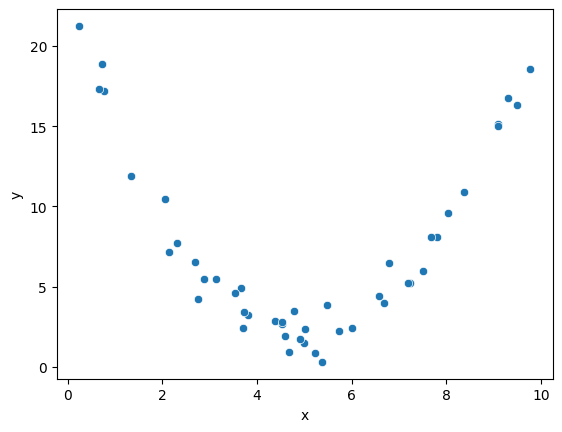

In [150]:
import seaborn as sns
sns.scatterplot(data=df, x="x", y="y")

In [151]:
import sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["y"]), df["y"], test_size=0.2, random_state=42)

In [152]:
# Linear pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
lin_pipe = Pipeline([("linreg", LinearRegression())])
lin_pipe.fit(X_train, y_train)

Pipeline(steps=[('linreg', LinearRegression())])

In [ ]:
print(lin_pipe.score(X_test, y_test))
print(lin_pipe.score(X_train, y_train))



-0.13629272799085346
0.01065389260659555


In [154]:
# Linear pipeline
from sklearn.preprocessing import PolynomialFeatures
# Polynomial pipeline (example: degree 2) #you can change degree 3,4..
poly_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linreg", LinearRegression())
])
poly_pipe.fit(X_train, y_train)

print(poly_pipe.score(X_test, y_test)) #here the performance is improved
print(poly_pipe.score(X_train, y_train))

0.9570397341869517
0.9753817173968149


In [155]:
print(f"Polynomial Regression Coefficients: {poly_pipe.named_steps['linreg'].coef_}")
print(f"Polynomial Regression Intercept: {poly_pipe.named_steps['linreg'].intercept_}")

Polynomial Regression Coefficients: [ 0.         -8.17479824  0.80276536]
Polynomial Regression Intercept: 22.92599732456237


In [156]:
#the equation will be  [1, x1,x1]
# y = m0*1+ m1*x1 + m2*x1(sqr) +b
# y=0(1)−8.17479824x+0.80276536x2+22.9259973